# 05_parser_validation.ipynb

> Validate the claim extractor against human coding
> Establishes inter-coder reliability, builds the gold standard by adjudication,
> and evaluates the LLM extractor against it. The decision gates defined here
> determine whether the study proceeds and whether rank is retained as a
> reported metric.
> A single extractor is evaluated. The rule-based parser was abandoned in 04,
> so the reconciliation and conflict-stratified reweighting present in an
> earlier version of this notebook no longer apply: the coding sample is now a
> simple stratified random draw, and the raw figures are the reported ones.

Coding sheet rows: 300   auto reference rows: 300
Extractor approach: llm_only
Extractor stability (feature): 1.0
Matched coded records: 300
Candidate features per record: median 12, range 12-12
Positive rate in the candidate set: 0.397
Saved: tab12_inter_coder_reliability.csv

Inter-coder reliability (ceiling for the extractor):


,Level,Cohen's kappa,N units
0,Feature,0.9820,3600
1,Direction,0.9985,1412
2,Rank,0.9764,1420


Disagreements requiring adjudication: 34
Adjudication loaded: 34 rows, 2 still open
Gold claims: 1,426   excluded (unadjudicated): 2

  Inter-coder kappa is computed over every item, including the ones
  the coders disputed. The extractor is then scored only on the items
  they agreed on. The two are not measured on the same set, and the
  extractor's score is inflated by that asymmetry.
  Complete adjudication.csv before treating the gates as meaningful.
Saved: tab13_extractor_validation.csv


,Extractor,Feature precision,Feature recall,Feature F1,Feature kappa,Direction accuracy,Direction kappa,Rank kappa,Rank tau,N feature units,N direction units,N rank units
0,gpt-5.6-terra,0.9979,0.9923,0.9951,0.9919,1.0,1.0,0.9951,0.9909,3600,1407,1415


Saved: tab14_decision_gates.csv
         Metric  Observed  Coder ceiling  Threshold  Met                                           Action if unmet
  Feature kappa    0.9919         0.9820        0.8 True Revise the extractor prompt or allowed-feature list in 04
Direction kappa    1.0000         0.9985        0.8 True  Sharpen the direction definition in the extractor prompt
     Rank kappa    0.9951         0.9764        0.7 True          Retain rank as an appendix-only secondary metric

Proceed to the main study: True
Rank reported as a primary metric: True

NOTE: Feature kappa (0.9919) exceeds the inter-coder ceiling (0.982). Inspect the adjudication: the gold standard may have been influenced by the automatic output.

NOTE: Direction kappa (1.0) exceeds the inter-coder ceiling (0.9985). Inspect the adjudication: the gold standard may have been influenced by the automatic output.

NOTE: Rank kappa (0.9951) exceeds the inter-coder ceiling (0.9764). Inspect the adjudication: the gold s

...

Saved: tab16_direction_extraction_errors.csv
Direction errors: 0


""


Saved: tab17_extraction_quality_by_condition.csv
Feature kappa spread across conditions      : 0.0249
Direction accuracy spread across conditions : 0.0000


,Domain,Prompt,N records,Feature kappa,Direction accuracy
0,churn,basic,50,0.9751,1.0
1,churn,constrained,50,1.0000,1.0
2,churn,verification,50,1.0000,1.0
3,credit,basic,50,0.9819,1.0
4,credit,constrained,50,0.9966,1.0
5,credit,verification,50,0.9965,1.0


Saved: fig12_extractor_validation.png / fig12_extractor_validation.pdf


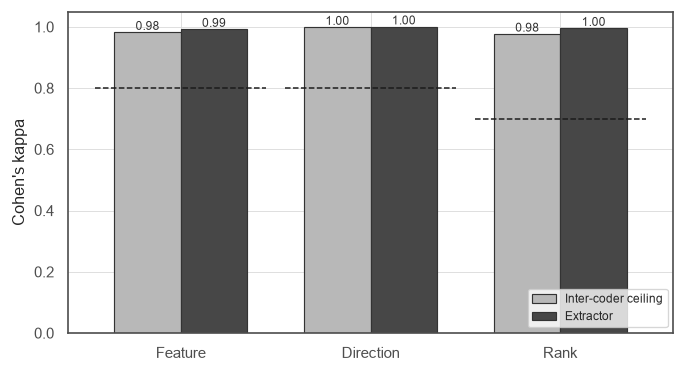

Saved: fig13_feature_precision_recall.png / fig13_feature_precision_recall.pdf


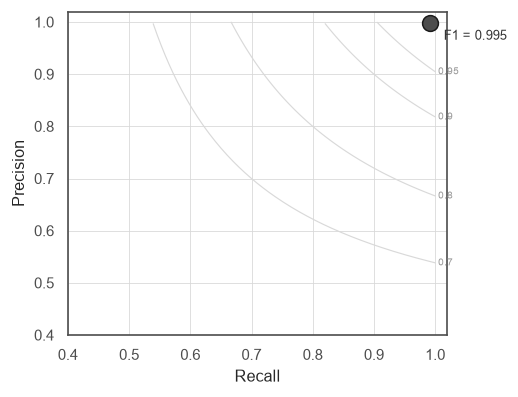

Saved: fig14_extraction_quality_by_condition.png / fig14_extraction_quality_by_condition.pdf


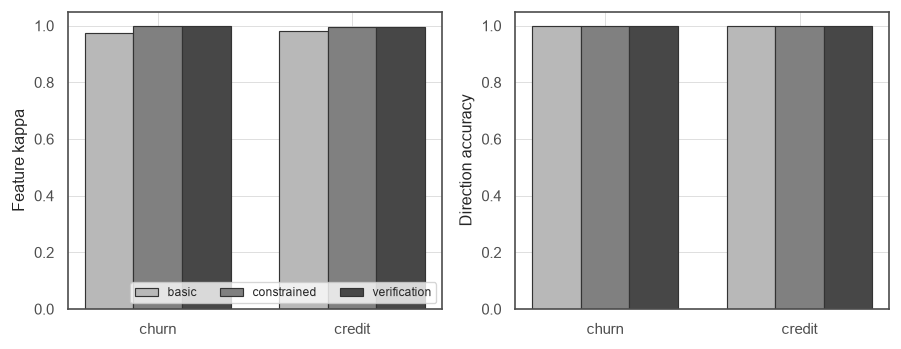

Saved: validation_summary.json
Saved: logs/05_run_20260915.json
Outputs:
  results\tables\tab12_inter_coder_reliability.csv
  results\tables\tab13_extractor_validation.csv
  results\tables\tab14_decision_gates.csv
  results\tables\tab15_feature_extraction_errors.csv
  results\tables\tab16_direction_extraction_errors.csv
  results\tables\tab17_extraction_quality_by_condition.csv
  results\figures\fig12_extractor_validation.pdf
  results\figures\fig12_extractor_validation.png
  results\figures\fig13_feature_precision_recall.pdf
  results\figures\fig13_feature_precision_recall.png
  results\figures\fig14_extraction_quality_by_condition.pdf
  results\figures\fig14_extraction_quality_by_condition.png

Validation outcome
------------------
Inter-coder kappa      feature 0.982, direction 0.9985
Extractor kappa        feature 0.9919, direction 1.0, rank 0.9951
Extractor self-stability  1.0 (feature overlap across repeat runs)

Proceed to main study  True
Rank as primary metric True

Two distin

In [1]:
# ============================================================================
# 05_parser_validation.ipynb
# Validate the claim extractor against human coding
# Establishes inter-coder reliability, builds the gold standard by adjudication,
# and evaluates the LLM extractor against it. The decision gates defined here
# determine whether the study proceeds and whether rank is retained as a
# reported metric.
#
# A single extractor is evaluated. The rule-based parser was abandoned in 04,
# so the reconciliation and conflict-stratified reweighting present in an
# earlier version of this notebook no longer apply: the coding sample is now a
# simple stratified random draw, and the raw figures are the reported ones.
# ============================================================================


# [Cell 1] Imports and global configuration
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import cohen_kappa_score, precision_recall_fscore_support
from scipy.stats import kendalltau

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
LOG_DIR = ROOT / "logs"

for d in [DATA_DIR, FIG_DIR, TAB_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# [Cell 2] Plotting style: grayscale, publication settings
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette(sns.color_palette("gray", n_colors=8))

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.5,
    "axes.edgecolor": "0.3",
    "axes.labelcolor": "0.15",
    "text.color": "0.15",
    "xtick.color": "0.3",
    "ytick.color": "0.3",
    "image.cmap": "gray",
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})


def save_fig(fig, name):
    """Save a figure as both PNG and PDF at 600 dpi. No caption is added."""
    for ext in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")
    print(f"Saved: {name}.png / {name}.pdf")


def save_table(df, name, index=False):
    """Save a table as CSV under results/tables."""
    df.to_csv(TAB_DIR / f"{name}.csv", index=index, encoding="utf-8-sig")
    print(f"Saved: {name}.csv")


# [Cell 3] Validation configuration
# Decision gates. These are pre-registered: the study proceeds only if the
# feature and direction gates are met. Rank is reported as a primary metric
# only if its gate is also met, otherwise it is relegated to the appendix.
GATES = {
    "feature_kappa": 0.80,
    "direction_kappa": 0.80,
    "rank_kappa": 0.70,
}


# [Cell 4] Load the coded sheet, the automatic extraction and the pilot
coding = pd.read_csv(DATA_DIR / "manual_coding_sheet.csv")
auto_ref = pd.read_csv(DATA_DIR / "coding_auto_reference.csv")
print(f"Coding sheet rows: {len(coding)}   auto reference rows: {len(auto_ref)}")

required = ["coder1_features", "coder1_directions",
            "coder2_features", "coder2_directions"]
blank = coding[required].isna().any(axis=1) | (
    coding[required].astype(str).apply(lambda s: s.str.strip() == "").any(axis=1)
)
if blank.any():
    raise ValueError(
        f"{blank.sum()} of {len(coding)} rows are not yet coded.\n"
        f"Two coders must complete coder1_* and coder2_* in "
        f"data/manual_coding_sheet.csv, working independently, before this "
        f"notebook can run. This is a deliberate stop, not a failure."
    )

with open(DATA_DIR / "pilot_extractions.json", encoding="utf-8") as f:
    pilot = json.load(f)

with open(DATA_DIR / "extractor_config.json", encoding="utf-8") as f:
    extractor_config = json.load(f)

print(f"Extractor approach: {extractor_config['approach']}")
print(f"Extractor stability (feature): "
      f"{extractor_config['stability']['Feature Jaccard']}")


# [Cell 5] Parse the semicolon-delimited coding columns
def parse_coded(features_str, directions_str):
    """Turn the two coded strings into an ordered list of claim dictionaries."""
    if pd.isna(features_str) or str(features_str).strip() == "":
        return []

    feats = [f.strip() for f in str(features_str).split(";") if f.strip()]
    dirs = [d.strip().lower() for d in str(directions_str).split(";")]

    # Pad so that a coder who omitted a direction does not shift the alignment
    dirs += ["unclear"] * (len(feats) - len(dirs))

    claims = []
    for i, (f, d) in enumerate(zip(feats, dirs[:len(feats)]), 1):
        claims.append({
            "feature": f,
            "direction": d if d in ("increases", "decreases") else None,
            "rank": i,
        })
    return claims


auto_by_id = auto_ref.set_index("coding_id").to_dict(orient="index")

coded = []
for _, row in coding.iterrows():
    ref = auto_by_id.get(row["coding_id"])
    if ref is None:
        print(f"WARNING: no automatic extraction for coding_id {row['coding_id']}")
        continue

    coded.append({
        "coding_id": row["coding_id"],
        "domain": row["domain"],
        "model": row["model"],
        "xai": row["xai"],
        "case_id": row["case_id"],
        "prompt": row["prompt"],
        "explanation": row["explanation"],
        "coder1": parse_coded(row["coder1_features"], row["coder1_directions"]),
        "coder2": parse_coded(row["coder2_features"], row["coder2_directions"]),
        "auto": parse_coded(ref["auto_features"], ref["auto_directions"]),
        "supplied": parse_coded(ref["supplied_features"], ref["supplied_directions"]),
    })

print(f"Matched coded records: {len(coded)}")


# [Cell 6] Feature universe for each coded record
# Reliability on feature identification is a binary decision per (explanation,
# candidate feature) pair. The candidate set is the union of everything any
# source mentioned, which is what the coders were asked to consider.
def claim_features(claims):
    """Feature identifiers present in a claim list."""
    return {c["feature"] for c in claims if c.get("feature")}


def claim_direction_map(claims):
    """Map feature to direction, leaving unresolved entries as None."""
    return {c["feature"]: c.get("direction") for c in claims if c.get("feature")}


# The candidate set is the allowed-feature list offered to both the extractor
# and the coder, not merely the union of what they happened to mention.
# Restricting it to mentioned features leaves almost no negative cases: with
# roughly 90 per cent of candidates present in the gold standard, chance
# agreement is already high and kappa collapses even under near-perfect
# agreement. Under the constrained prompt, where every supplied driver is
# mentioned, the negative class vanishes entirely and kappa is undefined.
allowed_by_id = dict(zip(coding["coding_id"], coding["allowed_features"]))

for rec in coded:
    allowed = [
        f.strip()
        for f in str(allowed_by_id.get(rec["coding_id"], "")).split(";")
        if f.strip()
    ]
    universe = set(allowed)
    # Anything a source named outside the offered list still counts
    for src in ["coder1", "coder2", "auto", "supplied"]:
        universe |= claim_features(rec[src])
    rec["universe"] = sorted(universe)

sizes = [len(r["universe"]) for r in coded]
n_pos = sum(len(claim_features(r["coder1"])) for r in coded)
pos_rate = n_pos / sum(sizes)

print(f"Candidate features per record: median {np.median(sizes):.0f}, "
      f"range {min(sizes)}-{max(sizes)}")
print(f"Positive rate in the candidate set: {pos_rate:.3f}")
if pos_rate > 0.7:
    print("NOTE: the candidate set remains heavily skewed toward positives. "
          "Kappa will be conservative; report F1 alongside it.")


# [Cell 7] Inter-coder reliability
# Reported before the gold standard is built, because agreement between the two
# human coders sets the ceiling for any automatic extractor. An extractor
# scoring above this ceiling would indicate a problem with the gold standard
# rather than an unusually good extractor.
def binary_vectors(rec, src_a, src_b):
    """Presence/absence vectors over the candidate feature set."""
    a, b = claim_features(rec[src_a]), claim_features(rec[src_b])
    return (
        [1 if f in a else 0 for f in rec["universe"]],
        [1 if f in b else 0 for f in rec["universe"]],
    )


def direction_vectors(rec, src_a, src_b):
    """Direction labels over features both sources identified and resolved."""
    da, db = claim_direction_map(rec[src_a]), claim_direction_map(rec[src_b])
    common = [f for f in set(da) & set(db) if da[f] and db[f]]
    return [da[f] for f in common], [db[f] for f in common]


def rank_pairs(rec, src_a, src_b):
    """Rank vectors over features both sources identified, in a fixed order."""
    ra = {c["feature"]: c.get("rank") for c in rec[src_a]}
    rb = {c["feature"]: c.get("rank") for c in rec[src_b]}
    common = sorted(f for f in set(ra) & set(rb)
                    if ra[f] is not None and rb[f] is not None)
    return [ra[f] for f in common], [rb[f] for f in common]


def pooled_kappa(records, src_a, src_b, level):
    """Cohen's kappa pooled across records at the given comparison level."""
    va, vb = [], []
    for rec in records:
        if level == "feature":
            a, b = binary_vectors(rec, src_a, src_b)
        elif level == "direction":
            a, b = direction_vectors(rec, src_a, src_b)
        elif level == "rank":
            a, b = rank_pairs(rec, src_a, src_b)
        else:
            raise ValueError(level)
        va.extend(a)
        vb.extend(b)

    if len(va) < 2 or len(set(va) | set(vb)) < 2:
        return np.nan, len(va)

    weights = "quadratic" if level == "rank" else None
    return cohen_kappa_score(va, vb, weights=weights), len(va)


ic_rows = []
for level in ["feature", "direction", "rank"]:
    k, n = pooled_kappa(coded, "coder1", "coder2", level)
    ic_rows.append({
        "Level": level.capitalize(),
        "Cohen's kappa": round(k, 4),
        "N units": n,
    })

inter_coder = pd.DataFrame(ic_rows)
save_table(inter_coder, "tab12_inter_coder_reliability")
print("\nInter-coder reliability (ceiling for the extractor):")
display(inter_coder)


# [Cell 8] Adjudication
# Where the two coders agree, the agreed claim becomes the gold standard.
# Where they disagree, a human adjudicates. Unadjudicated disagreements are
# excluded from evaluation rather than resolved by majority vote with the
# extractor, which would contaminate the reference the extractor is judged by.
ADJUDICATION_FILE = DATA_DIR / "adjudication.csv"


def build_disagreements(records):
    """Every coder disagreement that requires adjudication."""
    rows = []
    for rec in records:
        d1, d2 = claim_direction_map(rec["coder1"]), claim_direction_map(rec["coder2"])
        for feat in sorted(set(d1) | set(d2)):
            in1, in2 = feat in d1, feat in d2
            if not (in1 and in2):
                rows.append({
                    "coding_id": rec["coding_id"], "feature": feat,
                    "type": "presence",
                    "coder1": "present" if in1 else "absent",
                    "coder2": "present" if in2 else "absent",
                    "explanation_excerpt": str(rec["explanation"])[:200],
                    "adjudicated": "",
                })
            elif d1[feat] != d2[feat]:
                rows.append({
                    "coding_id": rec["coding_id"], "feature": feat,
                    "type": "direction",
                    "coder1": str(d1[feat]), "coder2": str(d2[feat]),
                    "explanation_excerpt": str(rec["explanation"])[:200],
                    "adjudicated": "",
                })
    return pd.DataFrame(rows)


disagreements = build_disagreements(coded)
print(f"Disagreements requiring adjudication: {len(disagreements)}")

if not ADJUDICATION_FILE.exists():
    disagreements.to_csv(ADJUDICATION_FILE, index=False, encoding="utf-8-sig")
    print(
        "\nSaved: adjudication.csv\n"
        "  Fill the 'adjudicated' column, then re-run this notebook.\n"
        "  For type=presence write 'present' or 'absent'.\n"
        "  For type=direction write 'increases' or 'decreases'.\n"
        "  Rows left blank are excluded from evaluation."
    )
    adjudication = None
else:
    adjudication = pd.read_csv(ADJUDICATION_FILE)
    open_rows = (
        adjudication["adjudicated"].isna()
        | (adjudication["adjudicated"].astype(str).str.strip() == "")
    ).sum()
    print(f"Adjudication loaded: {len(adjudication)} rows, {open_rows} still open")


# [Cell 9] Assemble the gold standard
def build_gold(records, adjudication_df):
    """Gold claims: coder agreement plus adjudicated resolutions."""
    adj = {}
    if adjudication_df is not None:
        for _, r in adjudication_df.iterrows():
            val = str(r["adjudicated"]).strip().lower()
            if val and val != "nan":
                adj[(r["coding_id"], r["feature"], r["type"])] = val

    for rec in records:
        d1, d2 = claim_direction_map(rec["coder1"]), claim_direction_map(rec["coder2"])
        r1 = {c["feature"]: c.get("rank") for c in rec["coder1"]}
        r2 = {c["feature"]: c.get("rank") for c in rec["coder2"]}

        gold, excluded = [], []
        for feat in sorted(set(d1) | set(d2)):
            in1, in2 = feat in d1, feat in d2

            # Presence
            if in1 and in2:
                present = True
            else:
                verdict = adj.get((rec["coding_id"], feat, "presence"))
                if verdict in ("present", "absent"):
                    present = verdict == "present"
                else:
                    excluded.append((feat, "presence"))
                    continue
            if not present:
                continue

            # Direction
            if in1 and in2 and d1[feat] == d2[feat]:
                direction = d1[feat]
            else:
                verdict = adj.get((rec["coding_id"], feat, "direction"))
                if verdict in ("increases", "decreases"):
                    direction = verdict
                elif in1 and not in2:
                    direction = d1[feat]
                elif in2 and not in1:
                    direction = d2[feat]
                else:
                    excluded.append((feat, "direction"))
                    continue

            ranks = [r for r in [r1.get(feat), r2.get(feat)] if r is not None]
            gold.append({
                "feature": feat,
                "direction": direction,
                "rank": float(np.mean(ranks)) if ranks else None,
            })

        gold.sort(key=lambda c: (c["rank"] is None, c["rank"]))
        for i, c in enumerate(gold, 1):
            c["rank"] = i

        rec["gold"] = gold
        rec["excluded"] = excluded

    return records


coded = build_gold(coded, adjudication)

n_gold = sum(len(r["gold"]) for r in coded)
n_excluded = sum(len(r["excluded"]) for r in coded)
print(f"Gold claims: {n_gold:,}   excluded (unadjudicated): {n_excluded:,}")

if n_excluded > 0:
    print(
        f"\nWARNING: {n_excluded} disagreements are unadjudicated and excluded "
        f"from the gold standard.\n"
        f"  Inter-coder kappa is computed over every item, including the ones\n"
        f"  the coders disputed. The extractor is then scored only on the items\n"
        f"  they agreed on. The two are not measured on the same set, and the\n"
        f"  extractor's score is inflated by that asymmetry.\n"
        f"  Complete adjudication.csv before treating the gates as meaningful."
    )


# [Cell 10] Extractor evaluation against the gold standard
def evaluate_extractor(records, src="auto"):
    """Feature-level precision/recall/F1 and kappa, plus direction and rank."""
    y_true, y_pred = [], []
    dir_true, dir_pred = [], []
    rank_true, rank_pred = [], []

    for rec in records:
        gold_f = claim_features(rec["gold"])
        pred_f = claim_features(rec[src])
        for feat in rec["universe"]:
            y_true.append(1 if feat in gold_f else 0)
            y_pred.append(1 if feat in pred_f else 0)

        gd, pdm = claim_direction_map(rec["gold"]), claim_direction_map(rec[src])
        for feat in set(gd) & set(pdm):
            if gd[feat] and pdm[feat]:
                dir_true.append(gd[feat])
                dir_pred.append(pdm[feat])

        a, b = rank_pairs(rec, "gold", src)
        rank_true.extend(a)
        rank_pred.extend(b)

    prec, rec_, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    return {
        "Feature precision": round(prec, 4),
        "Feature recall": round(rec_, 4),
        "Feature F1": round(f1, 4),
        "Feature kappa": round(cohen_kappa_score(y_true, y_pred), 4),
        "Direction accuracy": round(
            float(np.mean([a == b for a, b in zip(dir_true, dir_pred)]))
            if dir_true else np.nan, 4
        ),
        "Direction kappa": round(
            cohen_kappa_score(dir_true, dir_pred)
            if len(set(dir_true) | set(dir_pred)) > 1 else np.nan, 4
        ),
        "Rank kappa": round(
            cohen_kappa_score(rank_true, rank_pred, weights="quadratic")
            if len(rank_true) > 1 else np.nan, 4
        ),
        "Rank tau": round(
            kendalltau(rank_true, rank_pred).correlation
            if len(rank_true) > 1 else np.nan, 4
        ),
        "N feature units": len(y_true),
        "N direction units": len(dir_true),
        "N rank units": len(rank_true),
    }


evaluation = pd.DataFrame([evaluate_extractor(coded, "auto")])
evaluation.insert(0, "Extractor", extractor_config["extractor_model"])

save_table(evaluation, "tab13_extractor_validation")
display(evaluation)


# [Cell 11] Decision gates
result = evaluation.iloc[0]

gate_rows = [
    {
        "Metric": "Feature kappa",
        "Observed": result["Feature kappa"],
        "Coder ceiling": inter_coder.loc[0, "Cohen's kappa"],
        "Threshold": GATES["feature_kappa"],
        "Met": bool(result["Feature kappa"] >= GATES["feature_kappa"]),
        "Action if unmet": "Revise the extractor prompt or allowed-feature list in 04",
    },
    {
        "Metric": "Direction kappa",
        "Observed": result["Direction kappa"],
        "Coder ceiling": inter_coder.loc[1, "Cohen's kappa"],
        "Threshold": GATES["direction_kappa"],
        "Met": bool(result["Direction kappa"] >= GATES["direction_kappa"]),
        "Action if unmet": "Sharpen the direction definition in the extractor prompt",
    },
    {
        "Metric": "Rank kappa",
        "Observed": result["Rank kappa"],
        "Coder ceiling": inter_coder.loc[2, "Cohen's kappa"],
        "Threshold": GATES["rank_kappa"],
        "Met": bool(result["Rank kappa"] >= GATES["rank_kappa"]),
        "Action if unmet": "Retain rank as an appendix-only secondary metric",
    },
]

gates = pd.DataFrame(gate_rows)
save_table(gates, "tab14_decision_gates")
print(gates.to_string(index=False))

PROCEED = bool(gates.loc[0, "Met"] and gates.loc[1, "Met"])
RANK_PRIMARY = bool(gates.loc[2, "Met"])

print(f"\nProceed to the main study: {PROCEED}")
print(f"Rank reported as a primary metric: {RANK_PRIMARY}")

if not PROCEED:
    print("\nSTOP. Feature or direction extraction does not meet the "
          "pre-registered threshold. Revise the extractor in 04 and re-code, "
          "or report the study as inconclusive on extraction validity.")

# Extractor scoring above the human ceiling signals a gold-standard problem
for i, level in enumerate(["Feature", "Direction", "Rank"]):
    obs = gates.loc[i, "Observed"]
    ceil = gates.loc[i, "Coder ceiling"]
    if pd.notna(obs) and pd.notna(ceil) and obs > ceil:
        print(f"\nNOTE: {level} kappa ({obs}) exceeds the inter-coder ceiling "
              f"({ceil}). Inspect the adjudication: the gold standard may have "
              f"been influenced by the automatic output.")


# [Cell 12] Error analysis: feature level
fn, fp = Counter(), Counter()
for rec in coded:
    gold_f, pred_f = claim_features(rec["gold"]), claim_features(rec["auto"])
    for f in gold_f - pred_f:
        fn[f] += 1
    for f in pred_f - gold_f:
        fp[f] += 1

err_rows = [
    {
        "Feature": feat,
        "Missed (FN)": fn.get(feat, 0),
        "Spurious (FP)": fp.get(feat, 0),
        "Total errors": fn.get(feat, 0) + fp.get(feat, 0),
    }
    for feat in set(fn) | set(fp)
]

feature_errors = (
    pd.DataFrame(err_rows).sort_values("Total errors", ascending=False).head(20)
    if err_rows else pd.DataFrame(columns=["Feature", "Missed (FN)",
                                           "Spurious (FP)", "Total errors"])
)
save_table(feature_errors, "tab15_feature_extraction_errors")
display(feature_errors)


# [Cell 13] Error analysis: direction
# Direction errors are the most consequential for the study, because the whole
# stability measure rests on whether a driver was said to raise or lower risk.
dir_rows = []
for rec in coded:
    gd, pdm = claim_direction_map(rec["gold"]), claim_direction_map(rec["auto"])
    for feat in set(gd) & set(pdm):
        if gd[feat] and pdm[feat] and gd[feat] != pdm[feat]:
            dir_rows.append({
                "coding_id": rec["coding_id"],
                "domain": rec["domain"],
                "prompt": rec["prompt"],
                "feature": feat,
                "gold": gd[feat],
                "extracted": pdm[feat],
                "explanation_excerpt": str(rec["explanation"])[:180],
            })

direction_errors = pd.DataFrame(dir_rows)
save_table(direction_errors, "tab16_direction_extraction_errors")
print(f"Direction errors: {len(direction_errors)}")
display(direction_errors.head(15))


# [Cell 14] Extraction quality by condition
# Checks whether extraction quality is uniform across domains and prompts.
# Non-uniform error rates would confound the between-condition comparisons that
# 09 performs: an apparent difference in stability could instead be a
# difference in how reliably the extractor reads that condition's narratives.
cond_rows = []
frame = pd.DataFrame(coded)
for (domain, prompt), grp in frame.groupby(["domain", "prompt"]):
    recs = [coded[i] for i in grp.index]
    res = evaluate_extractor(recs, "auto")
    cond_rows.append({
        "Domain": domain,
        "Prompt": prompt,
        "N records": len(recs),
        "Feature kappa": res["Feature kappa"],
        "Direction accuracy": res["Direction accuracy"],
    })

by_condition = pd.DataFrame(cond_rows)
save_table(by_condition, "tab17_extraction_quality_by_condition")

spread_f = by_condition["Feature kappa"].max() - by_condition["Feature kappa"].min()
spread_d = by_condition["Direction accuracy"].max() - by_condition["Direction accuracy"].min()
print(f"Feature kappa spread across conditions      : {spread_f:.4f}")
print(f"Direction accuracy spread across conditions : {spread_d:.4f}")
if max(spread_f, spread_d) > 0.10:
    print("NOTE: extraction quality varies by condition. Report this as a "
          "limitation on the between-condition comparisons in 09.")

display(by_condition)


# [Cell 15] Figure: extractor performance against the human ceiling
metrics = ["Feature kappa", "Direction kappa", "Rank kappa"]
fig, ax = plt.subplots(figsize=(5.8, 3.2))

x = np.arange(len(metrics))
width = 0.35

extractor_vals = [result[m] for m in metrics]
ceiling_vals = inter_coder["Cohen's kappa"].tolist()

ax.bar(x - width / 2, ceiling_vals, width,
       color="0.72", edgecolor="0.2", linewidth=0.7, label="Inter-coder ceiling")
ax.bar(x + width / 2, extractor_vals, width,
       color="0.28", edgecolor="0.2", linewidth=0.7, label="Extractor")

for xi, v in zip(x - width / 2, ceiling_vals):
    if pd.notna(v):
        ax.text(xi, v, f"{v:.2f}", ha="center", va="bottom", fontsize=7, color="0.2")
for xi, v in zip(x + width / 2, extractor_vals):
    if pd.notna(v):
        ax.text(xi, v, f"{v:.2f}", ha="center", va="bottom", fontsize=7, color="0.2")

# Pre-registered thresholds
for xi, key in zip(x, ["feature_kappa", "direction_kappa", "rank_kappa"]):
    ax.plot([xi - 0.45, xi + 0.45], [GATES[key]] * 2,
            color="0.1", linestyle="--", linewidth=0.9)

ax.set_xticks(x)
ax.set_xticklabels(["Feature", "Direction", "Rank"])
ax.set_ylabel("Cohen's kappa")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=7, frameon=True, loc="lower right")

plt.tight_layout()
save_fig(fig, "fig12_extractor_validation")
plt.show()


# [Cell 16] Figure: precision and recall of feature identification
fig, ax = plt.subplots(figsize=(4.4, 3.4))

ax.scatter(
    result["Feature recall"], result["Feature precision"],
    s=90, color="0.3", edgecolor="0.1", linewidth=0.9, zorder=3,
)
ax.annotate(
    f"F1 = {result['Feature F1']:.3f}",
    (result["Feature recall"], result["Feature precision"]),
    textcoords="offset points", xytext=(8, -10), fontsize=8, color="0.2",
)

for f1 in [0.7, 0.8, 0.9, 0.95]:
    r = np.linspace(0.35, 1.0, 200)
    p = f1 * r / (2 * r - f1)
    m = (p >= 0) & (p <= 1)
    ax.plot(r[m], p[m], color="0.85", linewidth=0.7, zorder=1)
    if m.any():
        ax.text(r[m][-1], p[m][-1], f" {f1}", fontsize=6, color="0.6", va="center")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0.4, 1.02)
ax.set_ylim(0.4, 1.02)

plt.tight_layout()
save_fig(fig, "fig13_feature_precision_recall")
plt.show()


# [Cell 17] Figure: extraction quality by condition
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.0))

domains = sorted(by_condition["Domain"].unique())
prompts = sorted(by_condition["Prompt"].unique())
shades = ["0.72", "0.50", "0.28"]

for ax, metric in zip(axes, ["Feature kappa", "Direction accuracy"]):
    x = np.arange(len(domains))
    width = 0.25
    for i, p in enumerate(prompts):
        vals = [
            by_condition[
                (by_condition["Domain"] == d) & (by_condition["Prompt"] == p)
            ][metric].mean()
            for d in domains
        ]
        ax.bar(x + (i - 1) * width, vals, width,
               color=shades[i % 3], edgecolor="0.2", linewidth=0.7, label=p)
    ax.set_xticks(x)
    ax.set_xticklabels(domains)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    if metric == "Feature kappa":
        ax.legend(fontsize=7, frameon=True, ncol=3, loc="lower right")

plt.tight_layout()
save_fig(fig, "fig14_extraction_quality_by_condition")
plt.show()


# [Cell 18] Persist the validated configuration
# The error rates recorded here are carried forward so that the main analysis
# can account for measurement error rather than assuming perfect extraction.
validation_summary = {
    "approach": extractor_config["approach"],
    "extractor_model": extractor_config["extractor_model"],
    "n_coded_records": len(coded),
    "n_gold_claims": n_gold,
    "n_excluded_unadjudicated": n_excluded,
    "inter_coder": inter_coder.to_dict(orient="records"),
    "extractor": evaluation.to_dict(orient="records")[0],
    "gates": gates.to_dict(orient="records"),
    "proceed": PROCEED,
    "rank_primary": RANK_PRIMARY,
    "measurement_error": {
        "feature_fnr": round(1 - float(result["Feature recall"]), 4),
        "feature_fpr_proxy": round(1 - float(result["Feature precision"]), 4),
        "direction_error_rate": round(1 - float(result["Direction accuracy"]), 4),
    },
    "extractor_self_stability": extractor_config["stability"],
    "condition_spread": {
        "feature_kappa": round(float(spread_f), 4),
        "direction_accuracy": round(float(spread_d), 4),
    },
}

with open(DATA_DIR / "validation_summary.json", "w", encoding="utf-8") as f:
    json.dump(validation_summary, f, ensure_ascii=False, indent=2, default=str)
print("Saved: validation_summary.json")

stamp = pd.Timestamp.now().strftime("%Y%m%d")
with open(LOG_DIR / f"05_run_{stamp}.json", "w", encoding="utf-8") as f:
    json.dump(validation_summary, f, ensure_ascii=False, indent=2, default=str)
print(f"Saved: logs/05_run_{stamp}.json")


# [Cell 19] Verification and handover notes
print("Outputs:")
for p in sorted(TAB_DIR.glob("tab1[2-7]*")) + sorted(FIG_DIR.glob("fig1[2-4]*")):
    print(f"  {p.relative_to(ROOT)}")

print(f"""
Validation outcome
------------------
Inter-coder kappa      feature {inter_coder.loc[0, "Cohen's kappa"]}, direction {inter_coder.loc[1, "Cohen's kappa"]}
Extractor kappa        feature {result['Feature kappa']}, direction {result['Direction kappa']}, rank {result['Rank kappa']}
Extractor self-stability  {extractor_config['stability']['Feature Jaccard']} (feature overlap across repeat runs)

Proceed to main study  {PROCEED}
Rank as primary metric {RANK_PRIMARY}

Two distinct quantities are reported and should not be conflated in the paper:
  - Validity   : does the extractor read narratives the way humans do? (this notebook)
  - Reliability: does it read the same narrative the same way twice? (04)

